# Milestone 2
---
## Vivaproducts Customer Purchasing Habits
by Jennifer Allen

7015 - Data Science
---
Link to the data available on kaggle [here](https://kaggle.com/datasets/a513877f9cce7f13d066132556f83fc993cafe45dc3d2841feca8442a1afaa80)

Four versions of the data should be available, these include:
- Full Dataset.csv
: The full dataset is the complete dataset before I split it for training/testing purposes.
- test.csv
: 20% of the complete dataset, for testing
- training.csv
: 64% of the complete dataset for training
- validation.csv
: 16% of the complete dataset for validation
---
### Exploratory Data Analysis







In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.option_context('mode.use_inf_as_na', True)

source_file = "/kaggle/input/customer-purchasing-habits/Full_Dataset_with_Formatted_Dates.csv"
df = pd.read_csv(source_file)


### Summary Statistics

In [2]:
print("Variables:")
print("----------")
for i in df.columns:
    print(i)
print("\n**************************\n")

print("Quick Look:")
print("-----------")
print(df.describe(), "\n")
print("**************************\n")

print("Rows & Columns:")
print("---------------")
print(df.shape,"\n")
print("**************************\n")

print("Sample:")
print("-------")
print(df.sample(5, random_state=1, ignore_index=True), "\n")
print("**************************\n")

print("Data types:")
print("-----------")
print(df.dtypes, "\n")
print("**************************\n")

Variables:
----------
Invoice#
Date
Name
Item_ID
Qty

**************************

Quick Look:
-----------
                Qty
count  16908.000000
mean       5.543648
std       16.830600
min      -24.000000
25%        1.000000
50%        2.000000
75%        4.000000
max      500.000000 

**************************

Rows & Columns:
---------------
(17032, 5) 

**************************

Sample:
-------
  Invoice#       Date          Name     Item_ID   Qty
0    51366  5/12/2020  Company_0136      VS2002   1.0
1    61613  1/19/2024  Company_0263   BJP-5/100   1.0
2    52221  9/14/2020  Company_0020  BJP-10/40P   1.0
3    57884  9/13/2022  Company_0129      VS0692  11.0
4    58863  1/19/2023  Company_0425    VS2002-S  20.0 

**************************

Data types:
-----------
Invoice#     object
Date         object
Name         object
Item_ID      object
Qty         float64
dtype: object 

**************************



Item Statistics

In [3]:
unique_items = df["Item_ID"].unique()
count_items = len(unique_items) 

print(f"Total Number of Unique Products: {count_items}\n")
print("**************************\n")

top_n_items = 10
top_items = df["Item_ID"].value_counts().head(top_n_items)
print("Top 10 Most Purchased Items:")
print("----------------------------")
print(top_items)

Total Number of Unique Products: 256

**************************

Top 10 Most Purchased Items:
----------------------------
Item_ID
VS2002-S      2319
VS0405        1994
BJP-5/40      1591
VS0404        1285
BJP-10/40      771
BJP-5/100      751
BJP-5/40P      737
BJP-20/100     704
BJP-5/30       531
VS2002         473
Name: count, dtype: int64


Pie Chart showing division of top 10 items, bar chart further down in the Visuals section

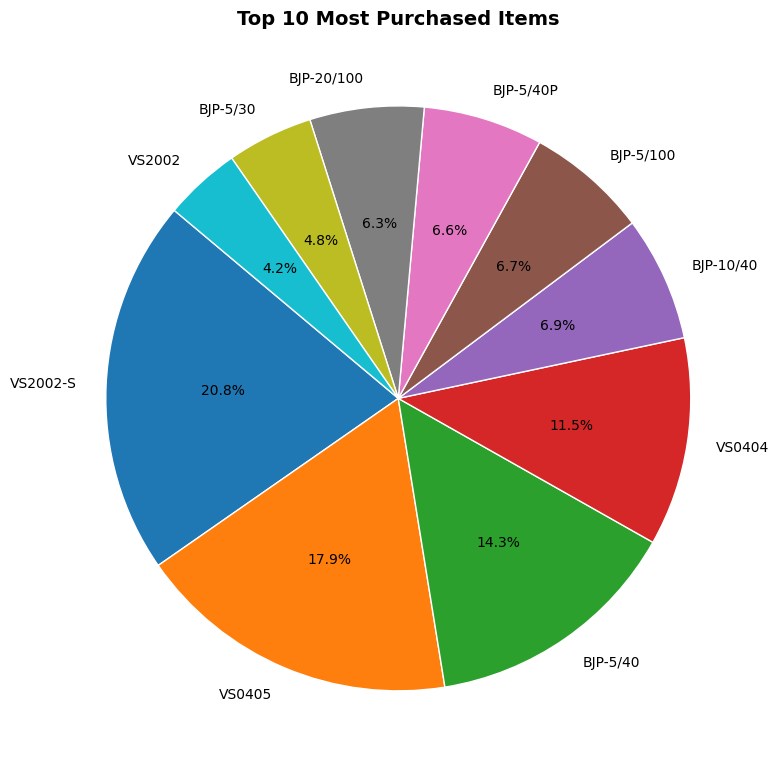

In [4]:
plt.figure(figsize=(8,8))
plt.pie(
    top_items.values,
    labels=top_items.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=plt.cm.tab10.colors,
    wedgeprops={"edgecolor": "white"}
)
plt.title("Top 10 Most Purchased Items", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

Customer Statistics

In [5]:
unique_cust = df["Name"].unique()
count_cust = len(unique_cust)

print(f"Total Number of Unique Customers: {count_cust}\n")

avg_purchases_cust = df.groupby("Name").size().mean()
print(f"Average Number of Purchases per Customer: {avg_purchases_cust:.2f}\n")

median_purchases_cust = df.groupby("Name").size().median()
print(f"Median Customer Purchases: {median_purchases_cust:.0f}\n")

print("NOTE: Median and Average purchases have a statistically significant gap.")

Total Number of Unique Customers: 615

Average Number of Purchases per Customer: 27.69

Median Customer Purchases: 7

NOTE: Median and Average purchases have a statistically significant gap.


Top 10 Customers with the Highest Volume Sales:
-----------------------------------------------
Name
Company_0083    15649.0
Company_0038    11268.0
Company_0020     4866.0
Company_0001     4116.0
Company_0066     3925.0
Company_0212     3335.0
Company_0059     1962.0
Company_0205     1450.0
Company_0008     1439.0
Company_0056     1328.0
Name: Qty, dtype: float64


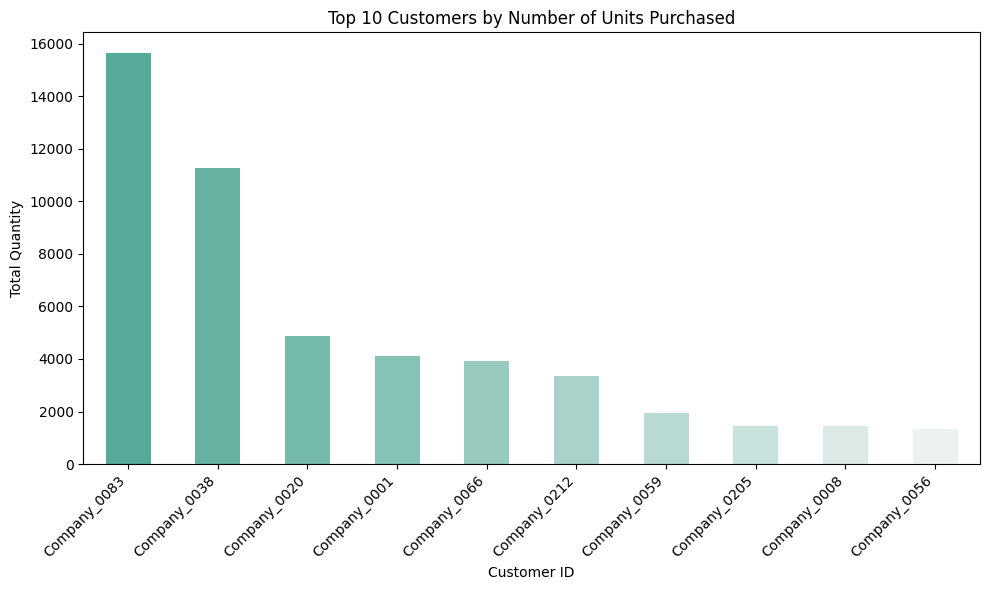

In [6]:
top_n_cust = 10
top_customers = df.groupby("Name")["Qty"].sum().sort_values(ascending=False).head(top_n_cust)

print(f"Top {top_n_cust} Customers with the Highest Volume Sales:")
print("-----------------------------------------------")
print(top_customers)

colors_top_cust = sns.color_palette("light:#5A9_r", len(top_customers))

plt.figure(figsize=(10,6))
top_customers.plot(kind="bar", color=colors_top_cust)
plt.title(f"Top {top_n_cust} Customers by Number of Units Purchased")
plt.xlabel("Customer ID")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [7]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

pd.set_option('display.float_format', lambda x: '%.2f' % x)

### Exploration with Visuals

Quick Look at 2020:

    Year Month_Name  Month  Num_Purchases
4   2020        Jan      1            222
3   2020        Feb      2            214
7   2020        Mar      3            209
0   2020        Apr      4            136
8   2020        May      5            178
6   2020        Jun      6            212
5   2020        Jul      7            227
1   2020        Aug      8            191
11  2020        Sep      9            219
10  2020        Oct     10            224
9   2020        Nov     11            224
2   2020        Dec     12            195


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

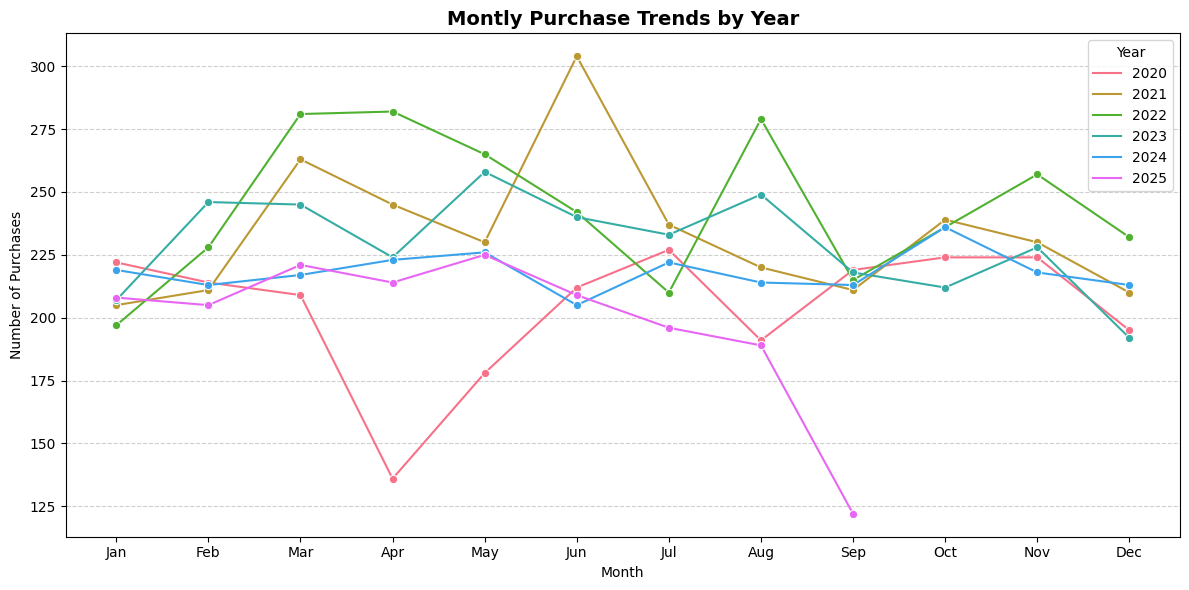

In [8]:
df["Month_Name"] = df["Date"].dt.strftime("%b")

def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

df["Season"] = df["Month"].apply(get_season)

monthly_trend = (
    df.groupby(["Year", "Month_Name", "Month"])["Invoice#"].nunique().reset_index(name="Num_Purchases")
)
monthly_trend = monthly_trend.sort_values(["Year", "Month"])
print("Quick Look at 2020:\n")
print(monthly_trend.head(12))

years = sorted(monthly_trend["Year"].unique())
palette = sns.color_palette("husl", n_colors=len(years))

plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_trend,
    x="Month_Name",
    y="Num_Purchases",
    hue="Year",
    hue_order=years,
    marker="o",
    palette=palette
)

plt.title("Montly Purchase Trends by Year", fontsize=14, weight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Purchases")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

And a 3-Month average of the above data

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

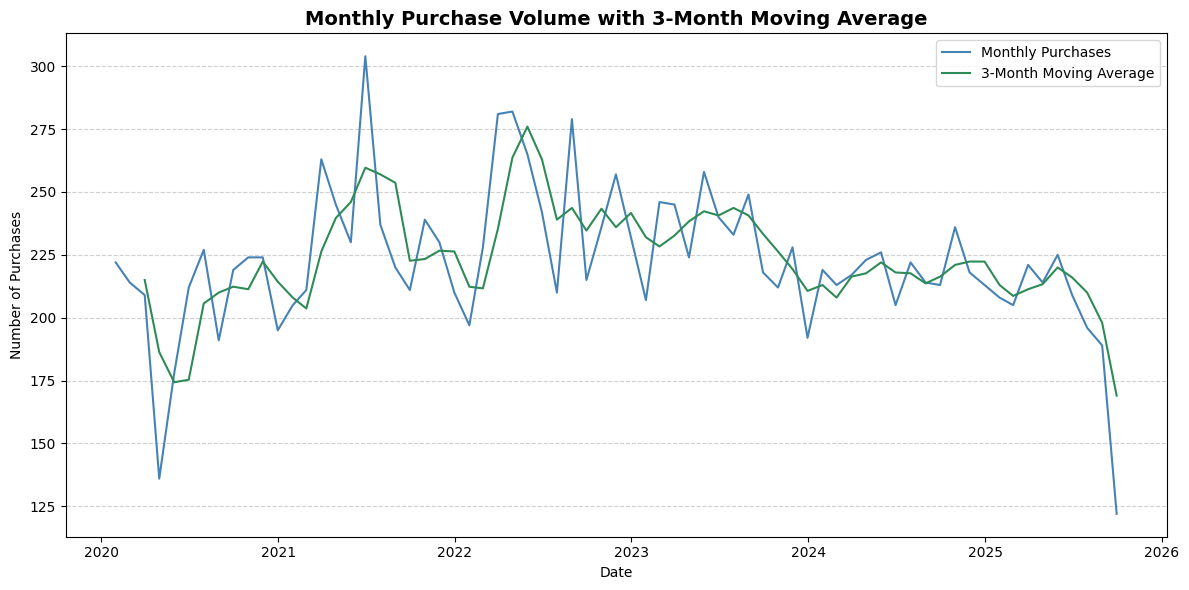

In [9]:
monthly_total = (
    df.groupby(pd.Grouper(key="Date", freq="ME"))["Invoice#"]
    .nunique()
    .reset_index(name="Num_Purchases")
)

monthly_total["Rolling_Avg"] = monthly_total["Num_Purchases"].rolling(3).mean()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_total, x="Date", y="Num_Purchases", label="Monthly Purchases", color="steelblue")
sns.lineplot(data=monthly_total, x="Date", y="Rolling_Avg", label="3-Month Moving Average", color="seagreen")

plt.title("Monthly Purchase Volume with 3-Month Moving Average", fontsize=14, weight="bold")
plt.xlabel("Date")
plt.ylabel("Number of Purchases")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Top 10 most frequently purchased items overall

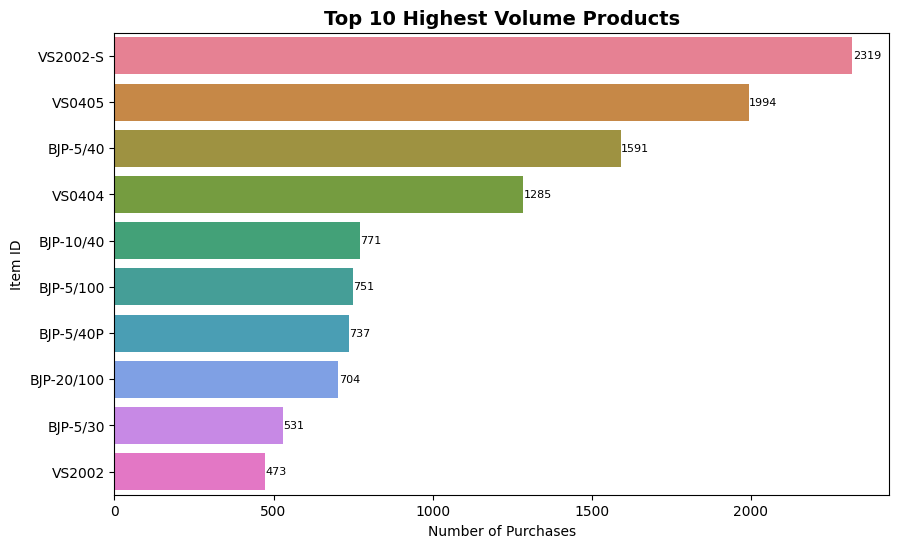

In [10]:
top_items = df["Item_ID"].value_counts().head(10)
colors = sns.color_palette("husl", len(top_items))

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_items.values, 
    y=top_items.index,
    #hue=top_items,
    #legend=False,  
    palette=colors)
plt.title("Top 10 Highest Volume Products", fontsize=14, weight="bold")
plt.xlabel("Number of Purchases")
plt.ylabel("Item ID")
for i, v in enumerate(top_items.values):
    plt.text(v + 0.5, i, str(v), color='black', va='center', fontsize=8)

plt.show()

Top 10 most frequently purchased item by year

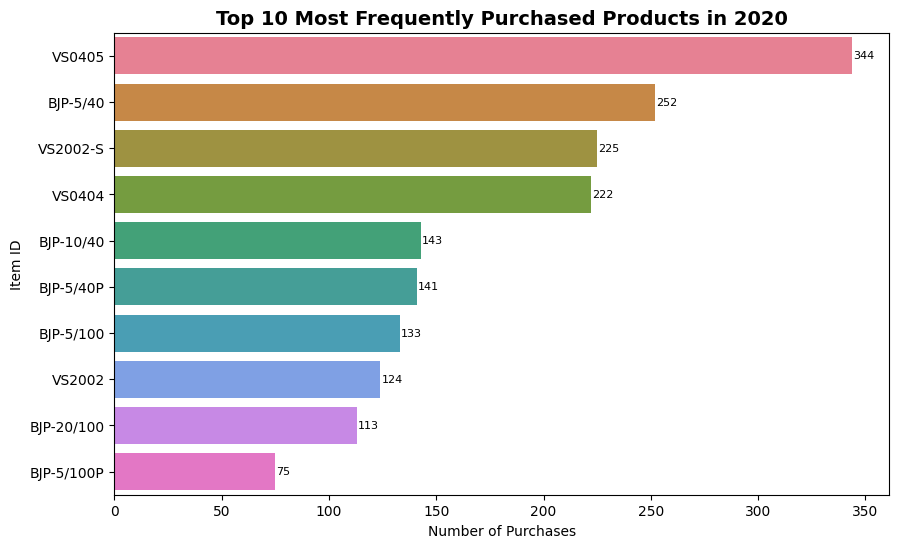

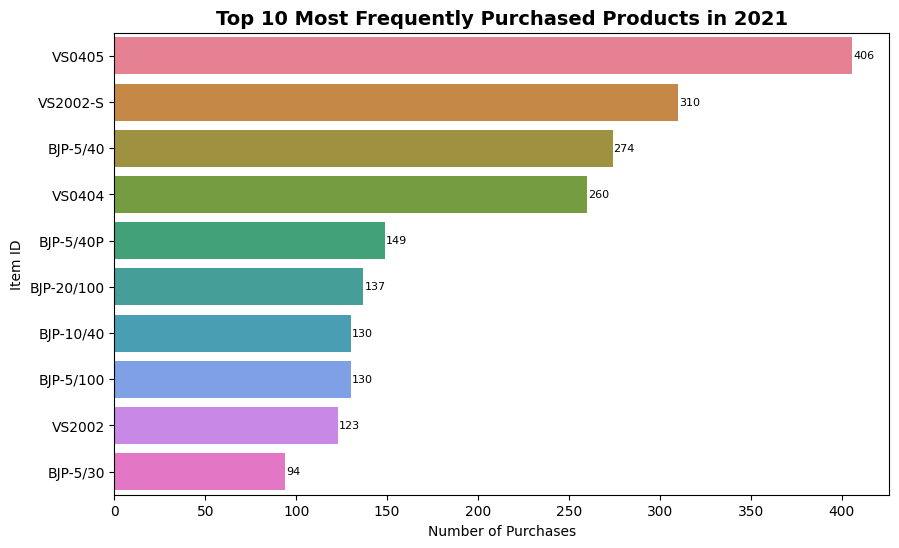

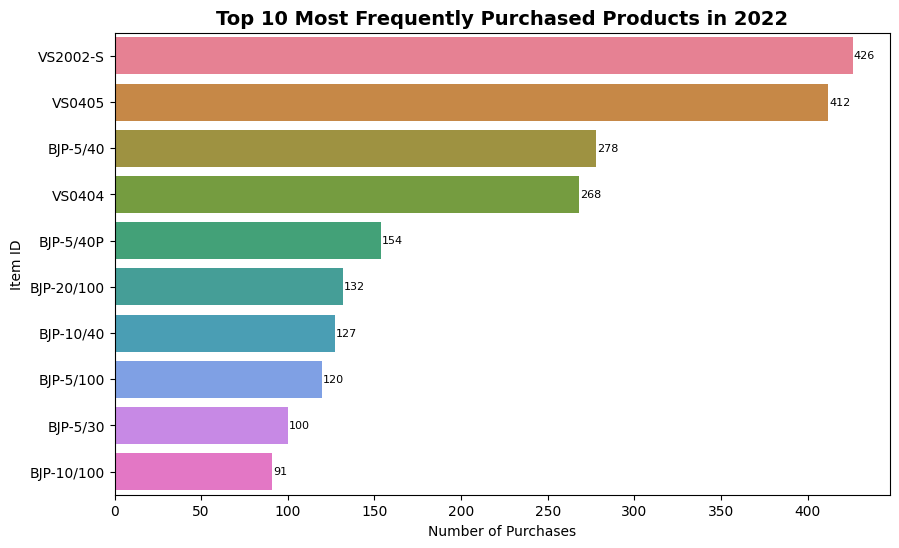

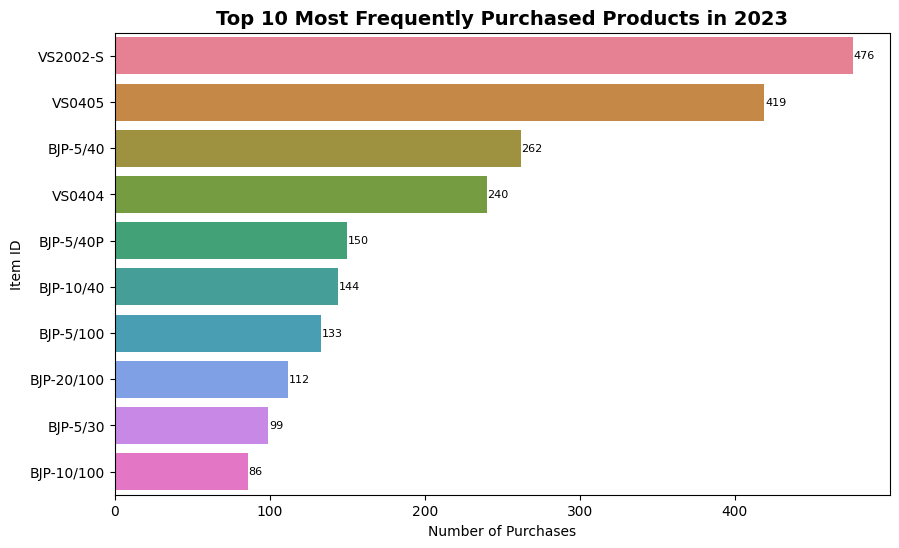

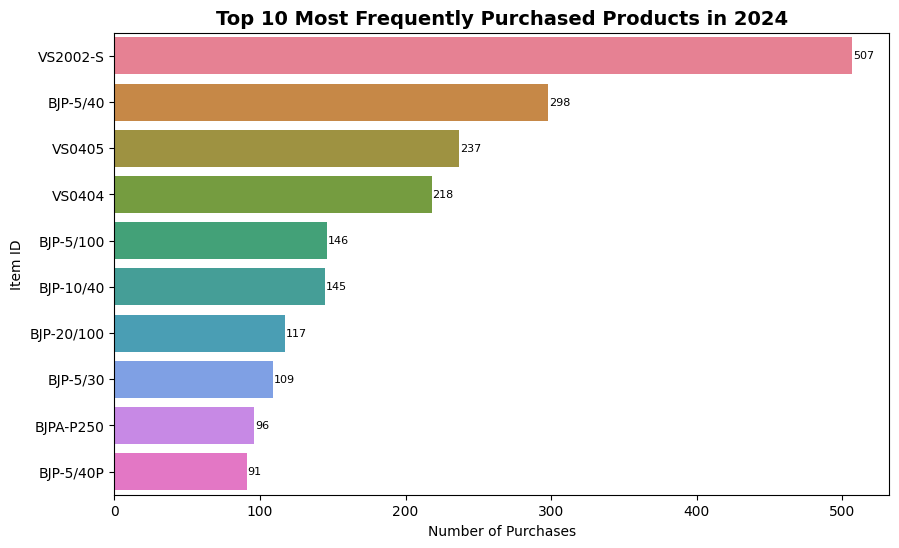

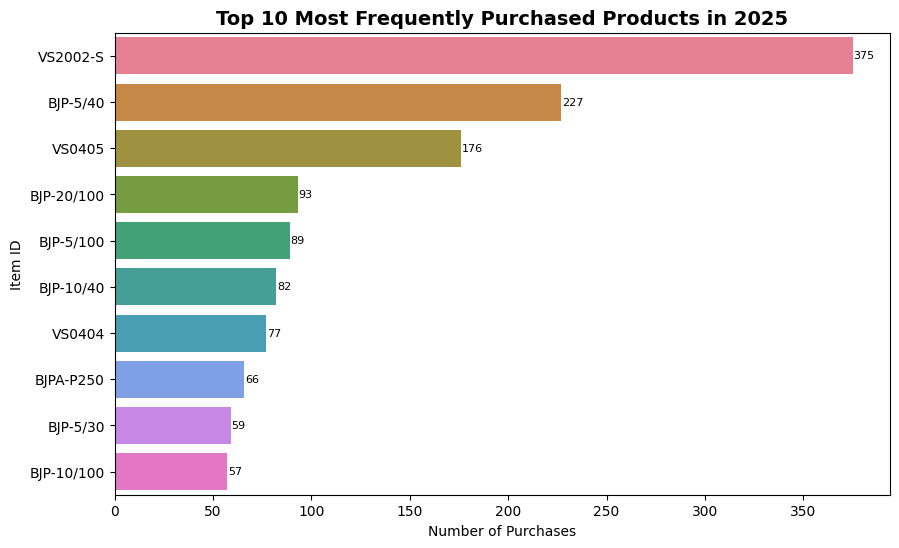

In [11]:
years = sorted(df["Year"].unique())

for year in years:
    top_items = df[df["Year"] == year]["Item_ID"].value_counts().head(10)
    colors = sns.color_palette("husl", len(top_items))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=top_items.values,
        y=top_items.index,
        #hue=top_items.index,
        #legend=False,
        palette=colors)

    plt.title(f"Top 10 Most Frequently Purchased Products in {int(year)}", fontsize=14, weight="bold")
    plt.xlabel("Number of Purchases")
    plt.ylabel("Item ID")
    for i, count in enumerate(top_items.values):
        plt.text(count + 0.5, i, str(count), color='black', va='center', fontsize=8)

    plt.show()

Total Monthly Purchases per Year

330


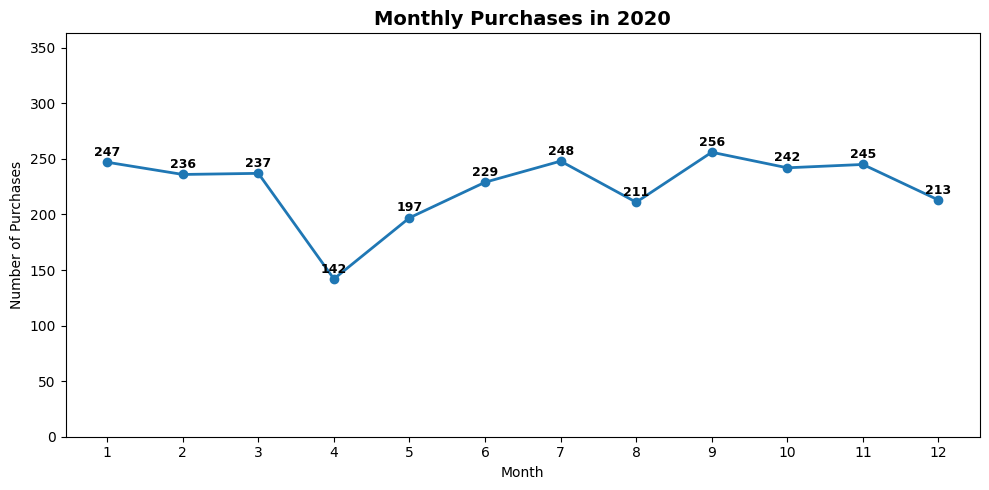

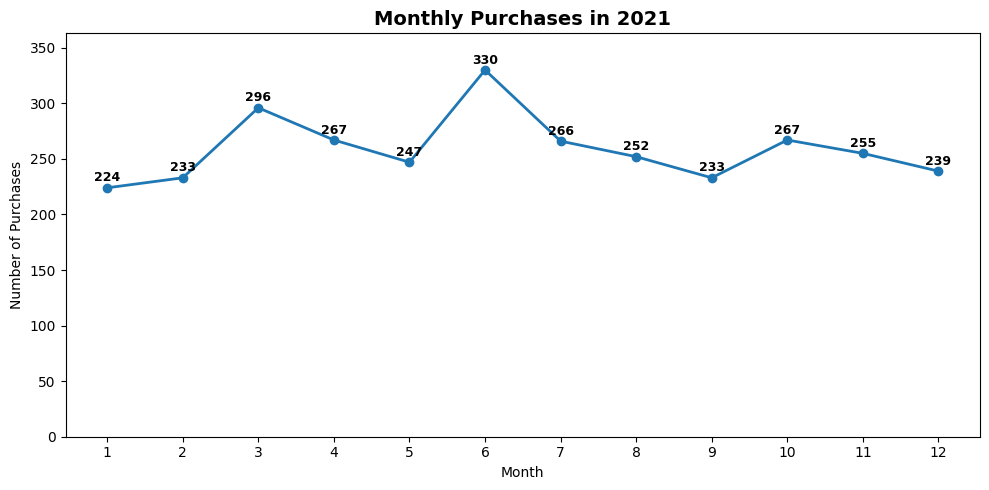

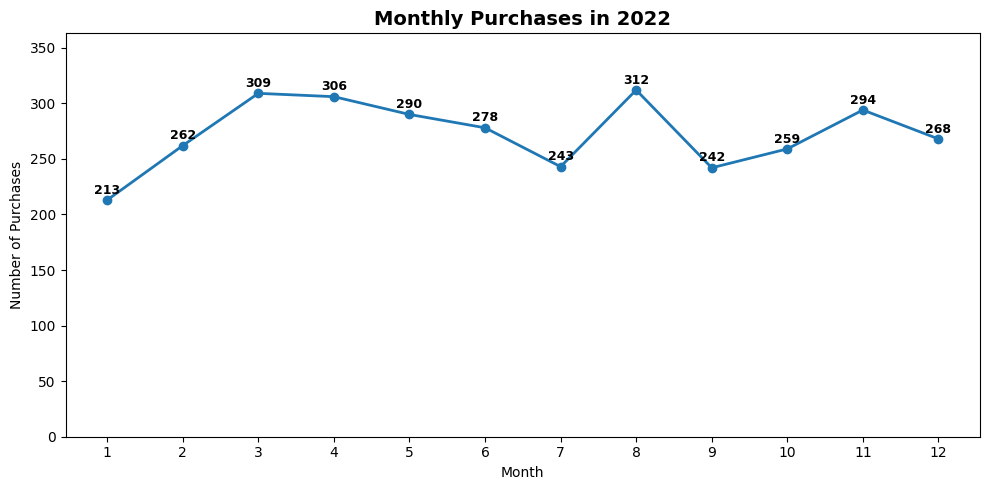

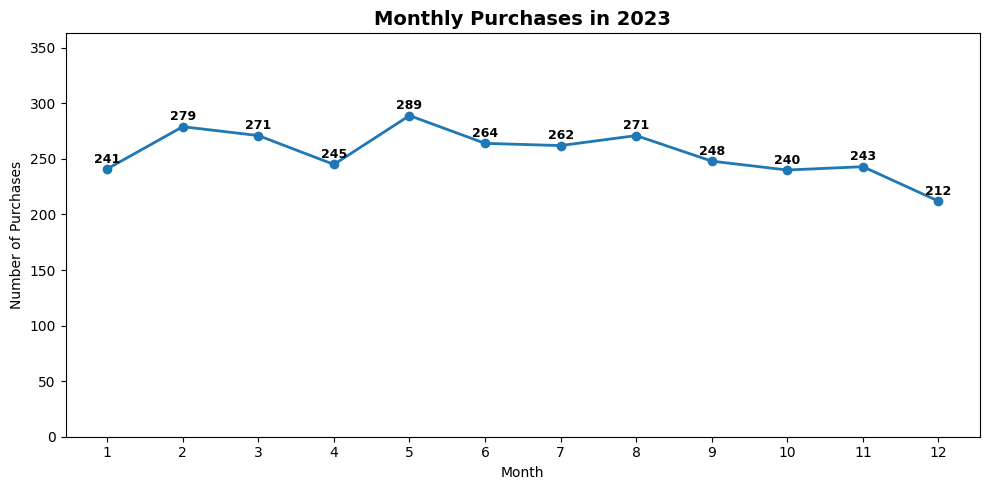

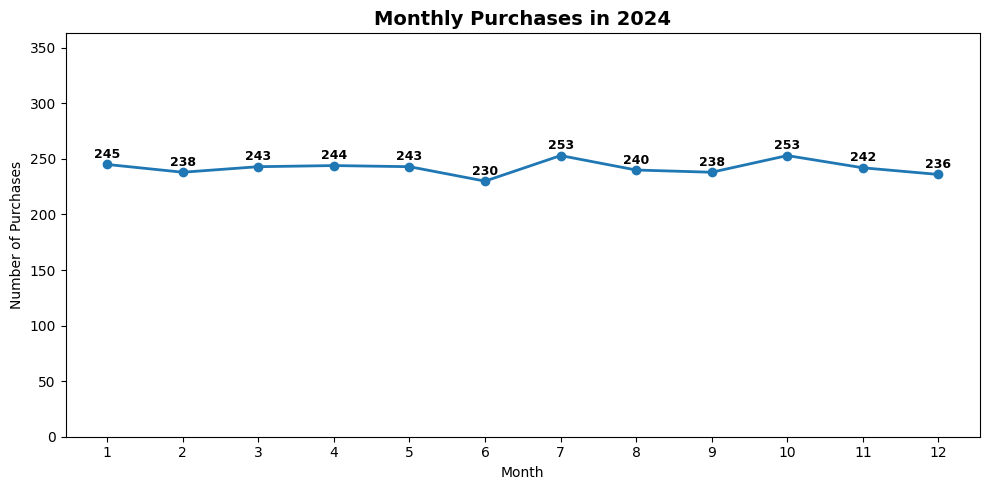

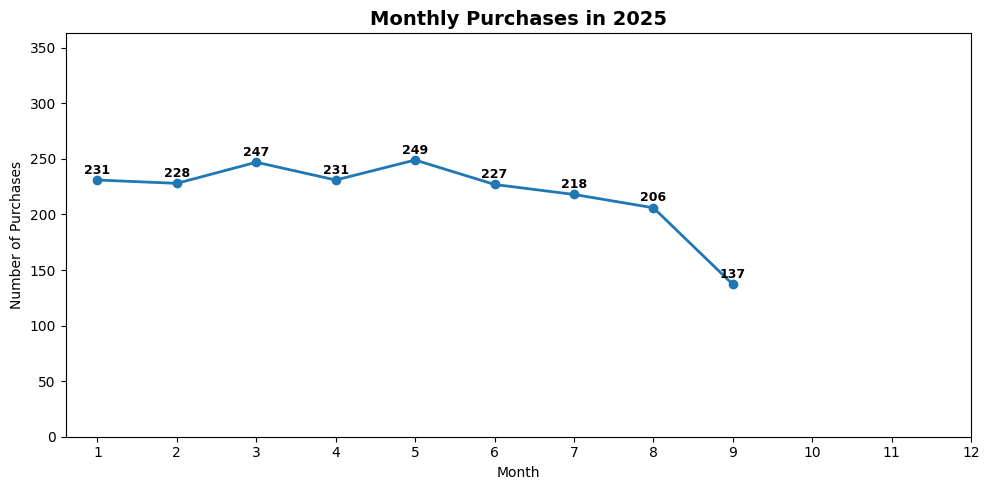

In [12]:
monthly_sales = df.groupby(["Year", "Month"]).size().reset_index(name="Purchases")

max_sales = monthly_sales["Purchases"].max()
print(max_sales)
y_max = max_sales * 1.1

years = sorted(df["Year"].unique())

for year in years:
    data = monthly_sales[monthly_sales["Year"] == year]
    
    plt.figure(figsize=(10,5))
    plt.plot(data["Month"], data["Purchases"], marker="o", linewidth=2)
    for i, row in data.iterrows():
        plt.text(
            row["Month"], row["Purchases"] + 3,  # +5 offsets the label slightly above the dot
            str(int(row["Purchases"])),
            ha="center", va="bottom", fontsize=9, weight="bold", color="black"
        )
    plt.title(f"Monthly Purchases in {int(year)}", fontsize=14, weight="bold")
    plt.xlabel("Month")
    plt.ylabel("Number of Purchases")
    plt.xticks(range(1,13))
    plt.ylim(0, y_max)
    plt.tight_layout()
    plt.show()

Average quantity of items purchased per customer

Overall average quantity of items purchased per customer: ~3
Overall median quantity of items purchased per customer: ~1


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


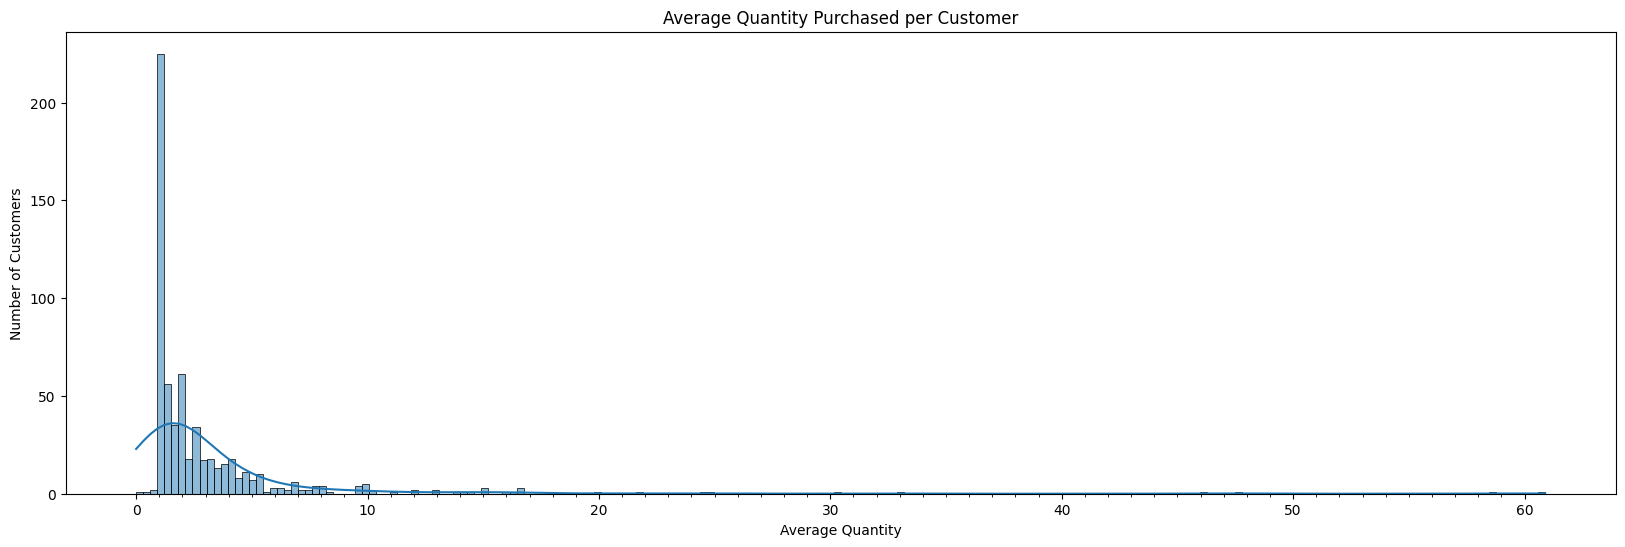

In [13]:
cust_avg = df.groupby("Name")["Qty"].mean().sort_values(ascending=True)
print(f"Overall average quantity of items purchased per customer: ~{int(cust_avg.mean())}")

print(f"Overall median quantity of items purchased per customer: ~{int(cust_avg.median())}")

max_avg = cust_avg.max()

plt.figure(figsize=(20, 6))
sns.histplot(cust_avg, bins=200, kde=True).set_xticks(ticks=np.arange(0, max_avg, 1), minor=True)
plt.title("Average Quantity Purchased per Customer")
plt.xlabel("Average Quantity")
plt.ylabel("Number of Customers")
plt.show()

There are some clear outliers here, I made this chart before I introduced some means to exclude outliers, seen below in the "Introducing Relevence" section. I came back here afterwares, so for more detail on IRQ, please see that section. For now, I am going to apply those techniques here.

Data without removing outliers:
Overall average quantity of items purchased per customer: ~3
Overall median quantity of items purchased per customer: ~1

Data after removing outliers:
Overall average quantity of items purchased per customer: ~2
Overall median quantity of items purchased per customer: ~1
Number of outliers: 56


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


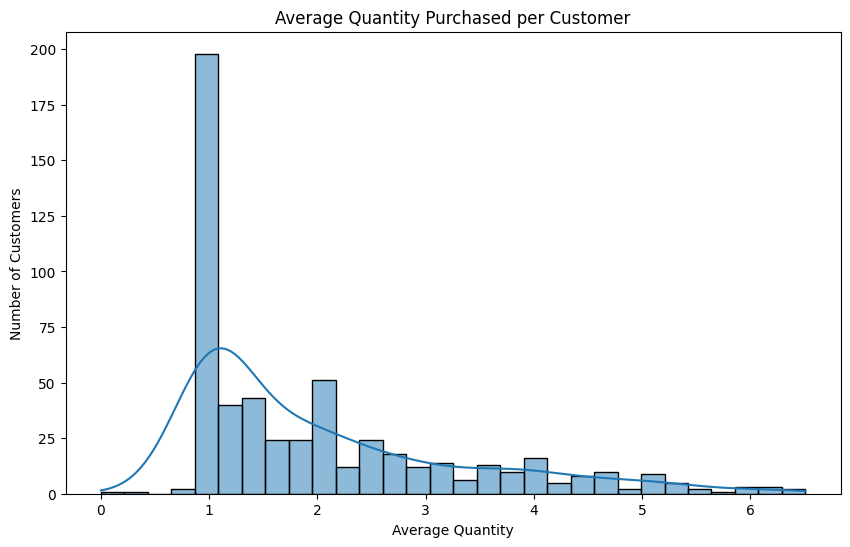

In [14]:

cust_avg = df.groupby("Name")["Qty"].mean().sort_values(ascending=True)

Q1 = cust_avg.quantile(0.25)
Q3 = cust_avg.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_avg_qty = cust_avg[(cust_avg < lower_bound) | (cust_avg > upper_bound)]
non_outliers_avg_qty = cust_avg[(cust_avg >= lower_bound) & (cust_avg <= upper_bound)]

print("Data without removing outliers:")
print(f"Overall average quantity of items purchased per customer: ~{int(cust_avg.mean())}")
print(f"Overall median quantity of items purchased per customer: ~{int(cust_avg.median())}")

print("\nData after removing outliers:")
print(f"Overall average quantity of items purchased per customer: ~{int(non_outliers_avg_qty.mean())}")
print(f"Overall median quantity of items purchased per customer: ~{int(non_outliers_avg_qty.median())}")
print(f"Number of outliers: {len(outliers_avg_qty)}")

max_avg = non_outliers_avg_qty.max()

plt.figure(figsize=(10, 6))
sns.histplot(non_outliers_avg_qty, bins=30, kde=True).set_xticks(ticks=np.arange(0, max_avg, 1), minor=True)
plt.title("Average Quantity Purchased per Customer")
plt.xlabel("Average Quantity")
plt.ylabel("Number of Customers")
plt.show()

## Correlations

Customer purchase frequency - Days between purchases by customer

Average days between purchases: ~37.04
Median days between purchases: 15.0


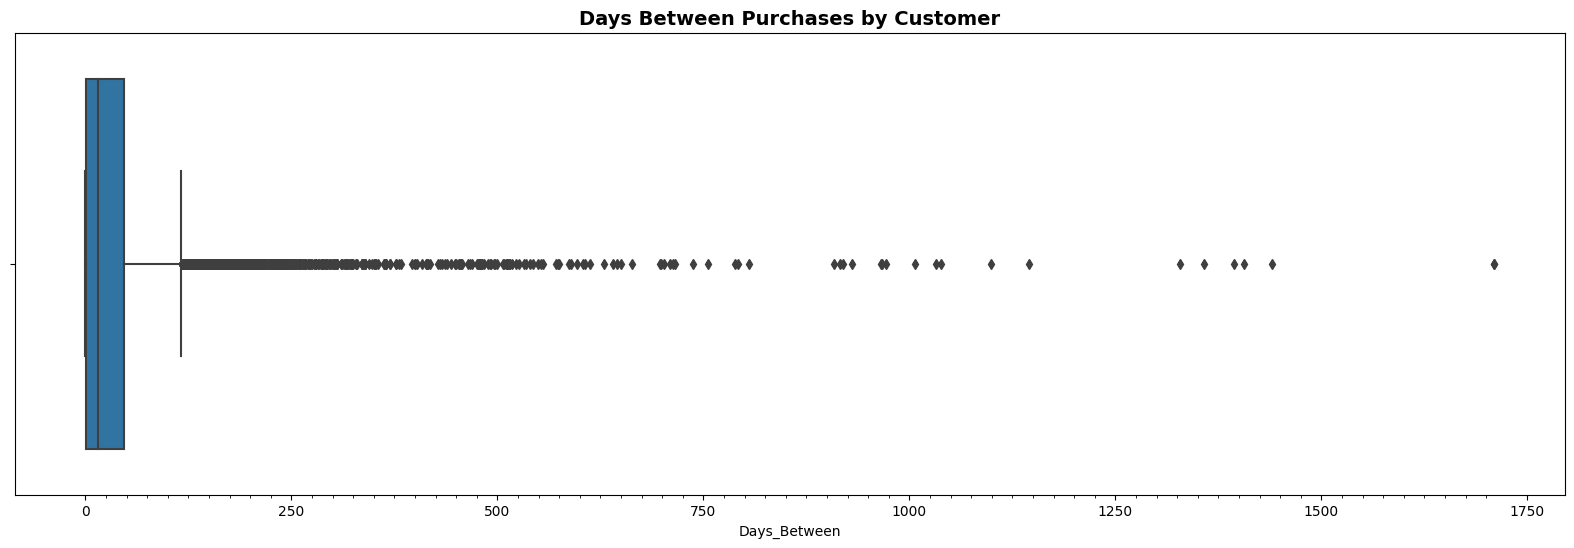

In [15]:
df = df.sort_values(["Name", "Date"])

df["Days_Between"] = df.groupby("Name")["Date"].diff().dt.days

mean_days_between = df["Days_Between"].mean()
median_days_between = df["Days_Between"].median()
print(f"Average days between purchases: ~{mean_days_between:.2f}")
print(f"Median days between purchases: {median_days_between}")

max_days = df["Days_Between"].max()

plt.figure(figsize=(20,6))
sns.boxplot(
    data=df, 
    x="Days_Between",
    ).set_xticks(
        ticks=np.arange(0, max_days, 25), minor=True)

plt.title("Days Between Purchases by Customer", fontsize=14, weight="bold")
plt.show()

Repeat customers - Grouped by Number of Purchases

In [16]:
repeat_cust = (
    df.groupby("Name")["Invoice#"]
    .nunique()
    .reset_index(name="Num_Purchases")
)

repeat_cust = repeat_cust[repeat_cust["Num_Purchases"] > 1]

cust_groups = (
    repeat_cust.groupby("Num_Purchases")["Name"]
    .apply(list)
    .reset_index(name="Cust_ID")
)

#reminder for unique num of customers!
unique_cust = len(df["Name"].unique())
print(f"Total Unique Customers: {unique_cust}")

print(f"Total Unique Repeat Customers: {len(repeat_cust)}")

print("\nCustomer groups:\n", cust_groups.head())

print(repeat_cust)

Total Unique Customers: 615
Total Unique Repeat Customers: 475

Customer groups:
    Num_Purchases                                            Cust_ID
0              2  [Company_0030, Company_0031, Company_0051, Com...
1              3  [Company_0012, Company_0137, Company_0189, Com...
2              4  [Company_0032, Company_0044, Company_0153, Com...
3              5  [Company_0120, Company_0133, Company_0162, Com...
4              6  [Company_0095, Company_0123, Company_0143, Com...
             Name  Num_Purchases
0    Company_0001           1459
2    Company_0003             45
3    Company_0004             78
4    Company_0005             79
5    Company_0006             72
..            ...            ...
603  Company_0606              6
604  Company_0607              3
605  Company_0608              2
608  Company_0611              2
613  Company_0616              2

[475 rows x 2 columns]


Repeat Customers - Visual

Most purchases: 1459
Mean purchases: ~24.94
Median purchases: 6


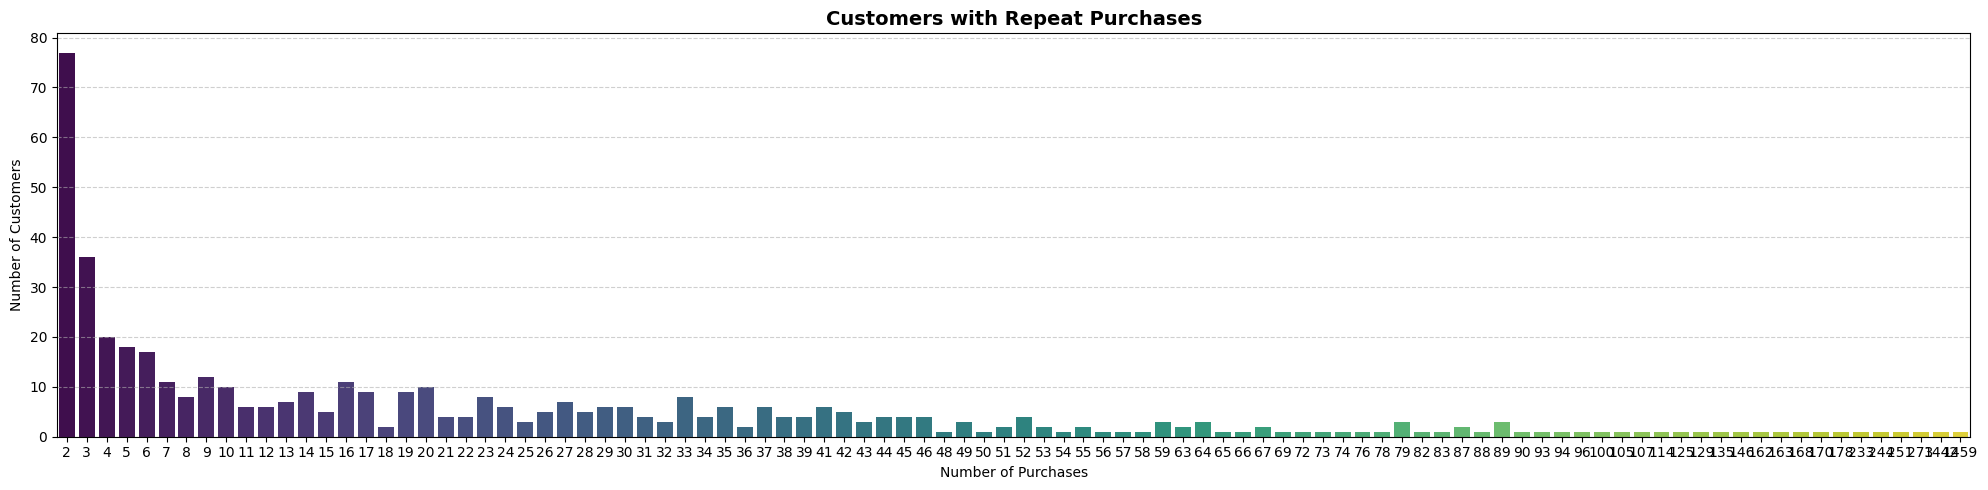

In [17]:
repeat_distribution = (
    df.groupby("Name")["Invoice#"]
    .nunique()
    # .value_counts()
    .sort_index()
    .reset_index(name="Num_Purchases")
)

# print(repeat_distribution)
repeat_distribution = repeat_distribution[repeat_distribution["Num_Purchases"] > 1]

repeat_distribution = repeat_distribution.sort_values(by="Num_Purchases", ascending=False)

repeat_summary = (
    repeat_distribution["Num_Purchases"]
    .value_counts()
    .sort_index()
    .reset_index()
)

repeat_summary.columns = ["Num_Purchases", "Num_Customers"]

purchase_counts = df.groupby('Name')['Invoice#'].nunique() 
max_purchases = purchase_counts.max()

print(f"Most purchases: {max_purchases}")
print(f"Mean purchases: ~{purchase_counts.mean():.2f}")
print(f"Median purchases: {int(purchase_counts.median())}")

plt.figure(figsize=(20, 5))
sns.barplot(
    data=repeat_summary,
    x="Num_Purchases",
    y="Num_Customers",
    #hue="Num_Purchases",
    #legend=False,
    palette="viridis"
)
plt.title("Customers with Repeat Purchases", fontsize=14, weight="bold")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Introducing some relevance
I'm using the Interquartile Range (IQR) to identify outliers. 

Where IQR is the third quartile minus the first quartile: Q3 - Q1 
and the data point is an outlier if x < Q1 - 1.5 * IQR ...OR... x > Q3 + 1.5 * IQR 

In [18]:
# Q1 = data.quantile(0.25)
# Q3 = data.quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

Days between purchases on repeat customers

Average days between purchases: ~37.04
Median days between purchases: 15.0

Summary of days between repeat purchases:
count   13223.00
mean       45.98
std        77.35
min         1.00
25%         7.00
50%        27.00
75%        56.00
max      1710.00
Name: Days_Between, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


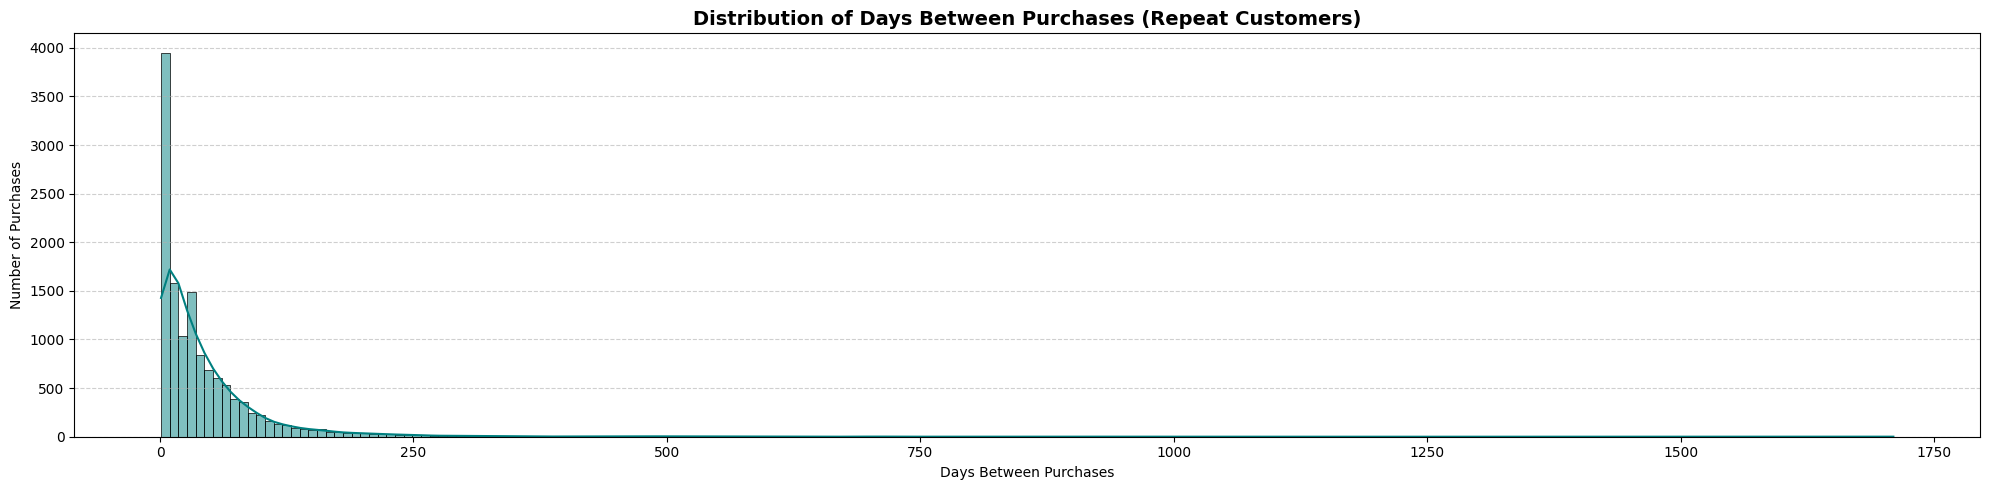

In [19]:
df = df.sort_values(["Name", "Date"])

df["Days_Between"] = df.groupby("Name")["Date"].diff().dt.days


mean_days_between = df["Days_Between"].mean()
median_days_between = df["Days_Between"].median()
print(f"Average days between purchases: ~{mean_days_between:.2f}")
print(f"Median days between purchases: {median_days_between}")

repeat_cust = (
    df.groupby("Name")["Invoice#"]
    .nunique()
    .reset_index(name="Num_Purchases")
)

repeat_cust = repeat_cust[repeat_cust["Num_Purchases"] > 1]

repeat_df = df[df["Name"].isin(repeat_cust["Name"])].copy()
repeat_df = repeat_df.dropna(subset=["Days_Between"])
repeat_df = repeat_df[repeat_df["Days_Between"] > 0]

data = repeat_df["Days_Between"].dropna()

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nSummary of days between repeat purchases:")
print(repeat_df["Days_Between"].describe())

plt.figure(figsize=(20, 5))
sns.histplot(repeat_df["Days_Between"], bins=200, kde=True, color="teal")
plt.title("Distribution of Days Between Purchases (Repeat Customers)", fontsize=14, weight="bold")
plt.xlabel("Days Between Purchases")
plt.ylabel("Number of Purchases")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

1        0.00
2        0.00
12       1.00
31       5.00
51       2.00
         ... 
16469    7.00
16437    0.00
16694   17.00
16606    0.00
16786   14.00
Name: Days_Between, Length: 16417, dtype: float64
12       1.00
31       5.00
51       2.00
65       3.00
94       2.00
         ... 
16398    7.00
16746   53.00
16469    7.00
16694   17.00
16786   14.00
Name: Days_Between, Length: 13223, dtype: float64
Q1: 7.0
Q3: 56.0
IQR:  49.0
Lower bound: -66.50, Upper bound: 129.50


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


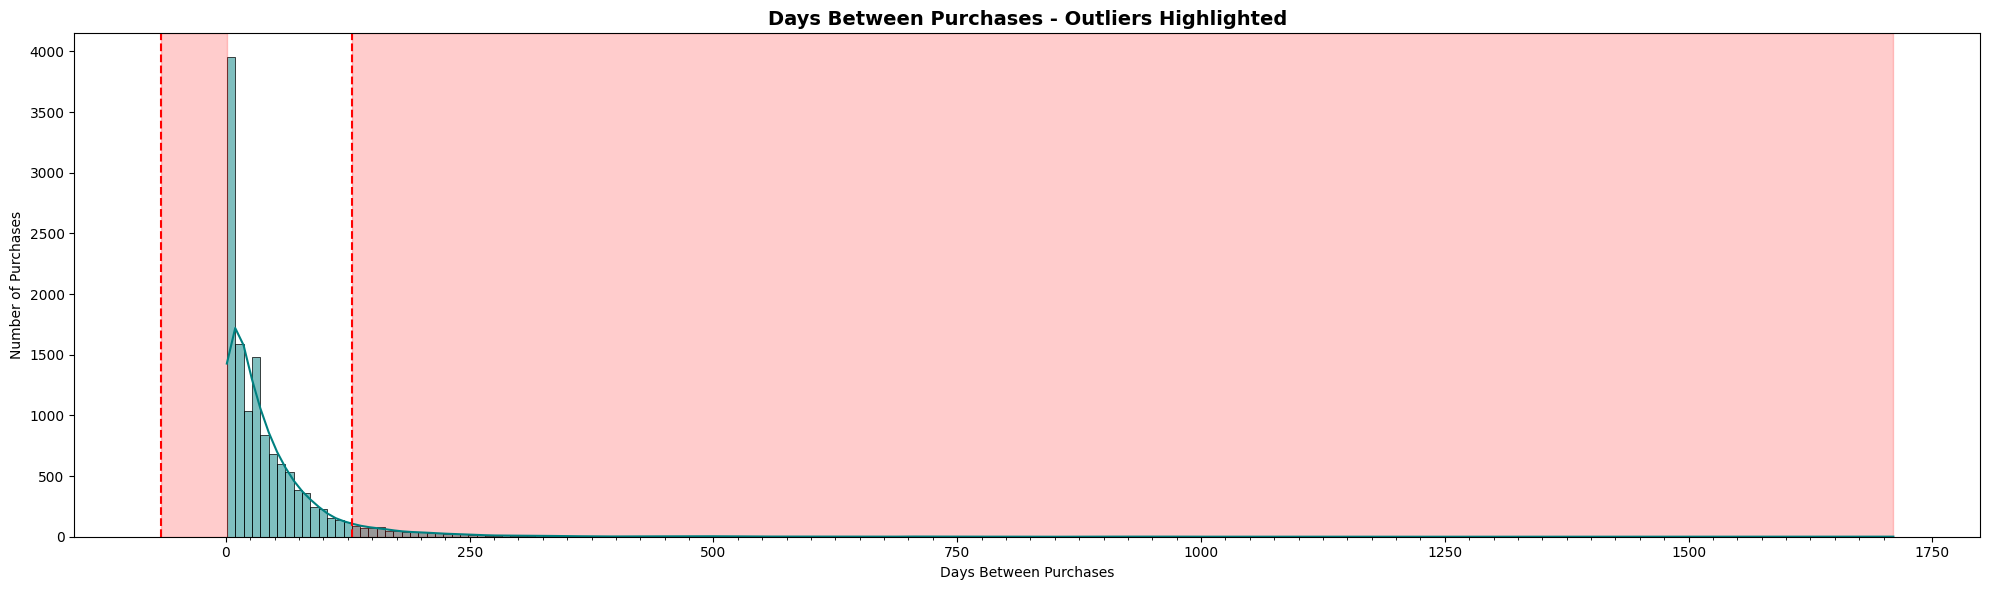

In [20]:

df["Days_Between"] = df.groupby("Name")["Date"].diff().dt.days

print(df["Days_Between"].dropna())

"""
max_days = df["Days_Between"].max()

print(f"Most days between purchases: {max_days}")
print(f"Average days between purchases: ~{df["Days_Between"].mean():.2f}")
print(f"Median days between purchases: {df["Days_Between"].median()}")
"""

repeat_cust = (
    df.groupby("Name")["Invoice#"]
    .nunique()
    .reset_index(name="Num_Purchases")
)

repeat_cust = repeat_cust[repeat_cust["Num_Purchases"] > 1]

repeat_df = df[df["Name"].isin(repeat_cust["Name"])].copy()
repeat_df = repeat_df.dropna(subset=["Days_Between"])
repeat_df = repeat_df[repeat_df["Days_Between"] > 0]

data = repeat_df["Days_Between"].dropna()

print(data)

Q1 = data.quantile(0.25)
print("Q1:",Q1)
Q3 = data.quantile(0.75)
print("Q3:", Q3)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("IQR: ", IQR)
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")


plt.figure(figsize=(20,6))
sns.histplot(data, bins=200, kde=True, color="teal").set_xticks(ticks=np.arange(0, max_days, 25), minor=True)
plt.axvspan(data.min(), lower_bound, color='red', alpha=0.2, label='Lower Outliers')
plt.axvspan(upper_bound, data.max(), color='red', alpha=0.2, label='Upper Outliers')
plt.axvline(lower_bound, color='red', linestyle='--')
plt.axvline(upper_bound, color='red', linestyle='--')
plt.title("Days Between Purchases - Outliers Highlighted", fontsize=14, weight="bold")
plt.xlabel("Days Between Purchases")
plt.ylabel("Number of Purchases")
plt.tight_layout()
plt.show()

With Outliers: 13223
Without Outliers: 12345


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


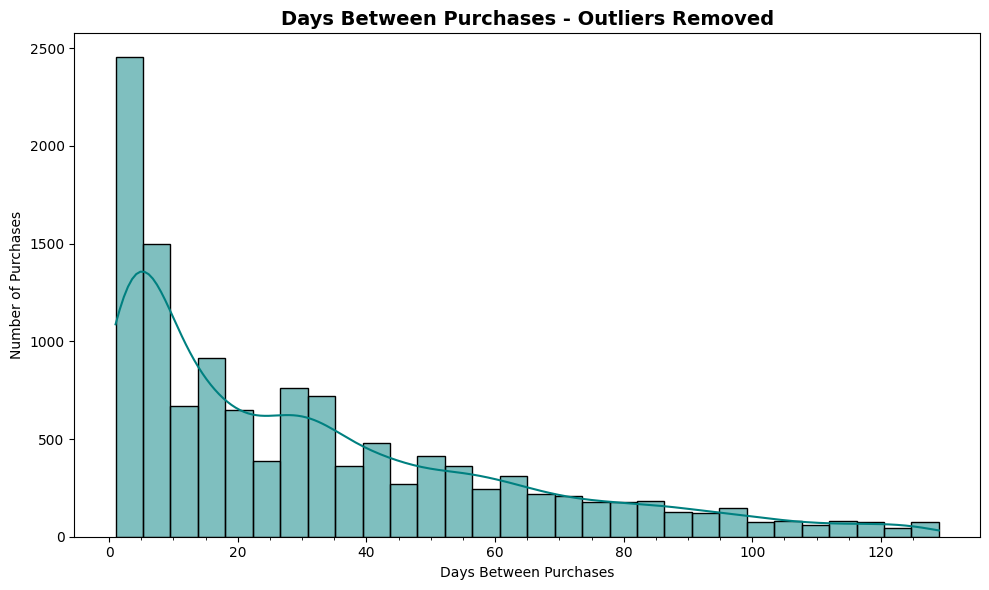

In [21]:
data_wo_outliers = data[(data >= lower_bound) & (data <= upper_bound)]

print(f"With Outliers: {len(data)}")
print(f"Without Outliers: {len(data_wo_outliers)}")

plt.figure(figsize=(10,6))
sns.histplot(data_wo_outliers, bins=30, kde=True, color="teal").set_xticks(ticks=np.arange(0, upper_bound, 5), minor=True)
plt.title("Days Between Purchases - Outliers Removed", fontsize=14, weight="bold")
plt.xlabel("Days Between Purchases")
plt.ylabel("Number of Purchases")
plt.tight_layout()
plt.show()

Average days between top customers

             Name  Avg_Days_Between  Num_Purchases
0    Company_0001              2.71           1459
17   Company_0020              2.30           1442
51   Company_0056              8.19            273
62   Company_0068              8.38            251
33   Company_0038              8.91            244
5    Company_0007              9.44            233
76   Company_0083             12.22            178
61   Company_0067             12.71            170
11   Company_0013             13.33            168
199  Company_0210             12.97            163


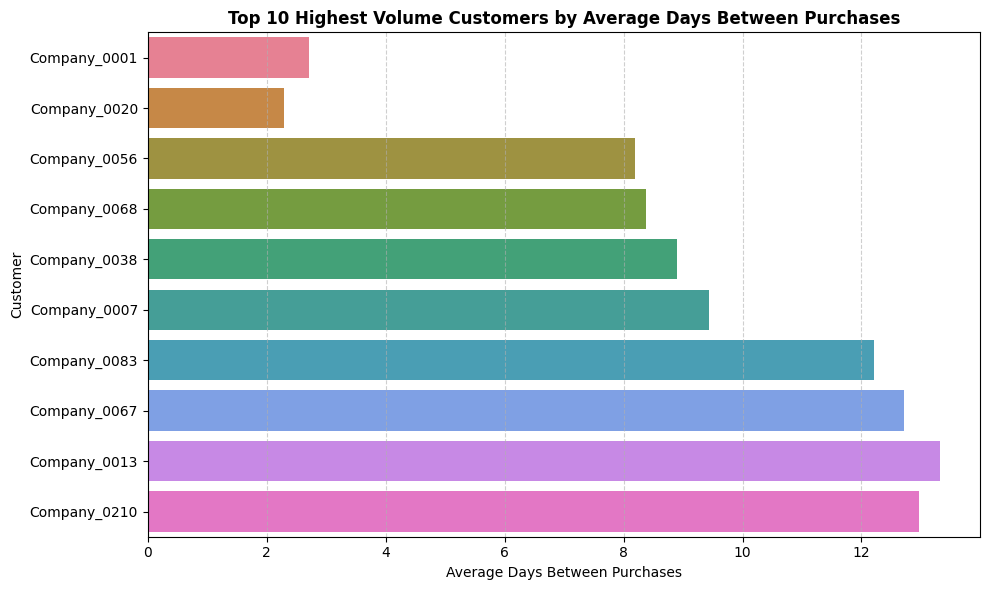

In [22]:
repeat_df = df[df["Name"].isin(repeat_cust["Name"])].copy()
repeat_df = repeat_df.dropna(subset=["Days_Between"])
repeat_df = repeat_df[repeat_df["Days_Between"] > 0]

avg_days = (
    repeat_df.groupby("Name")["Days_Between"].mean().reset_index(name="Avg_Days_Between")
)

avg_days = avg_days.merge(
    repeat_cust[["Name","Num_Purchases"]],
    on="Name",
    how="left"
)

avg_days = avg_days.sort_values("Num_Purchases", ascending=False)

print(avg_days.head(top_n_cust))


plt.figure(figsize=(10,6))
sns.barplot(
    data=avg_days.head(top_n_cust),
    x="Avg_Days_Between",
    y="Name",
    palette="husl"
)

plt.title(f"Top {top_n_cust} Highest Volume Customers by Average Days Between Purchases", fontsize=12, weight="bold")
plt.xlabel("Average Days Between Purchases")
plt.ylabel("Customer")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()